In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd

In [2]:
int_to_height = 8.33
bin_size_cm = 1.0
threshold_acl = 6 / int_to_height
threshold_lcm = 20 / int_to_height

#filename = '~/dune/light_file_processing/outputs/mr6-5_no_th/truth_reco_match_n1000.csv'
#filename = '~/dune/light_file_processing/outputs/gnn_training/truth_reco_match_n1000.csv'
filename = '/pscratch/sd/j/jvmead/to_dataframes/truth_reco_match_n1000_opt.csv'

xbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
ybins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)
zbins = np.arange(-70, 70 + bin_size_cm, bin_size_cm)

In [3]:
df_truth_reco = pd.read_csv(filename)
if not df_truth_reco.empty:
    print(df_truth_reco.head().to_string(index=False))
else:
    print("df_truth_reco is empty.")

 file_id  event_id  vertex_id  tpc_num   start_time  start_time_idx  vertex_x  vertex_y   vertex_z         enu  isCC  inelasticity        Q2  lep_pdg  nu_pdg  nphoton_tot     dE_tot  n_segments  x_mean_int  y_mean_int  z_mean_int  x_wmean_int  y_wmean_int  z_wmean_int  int_max_distance  int_tpc_num  n_int_per_tpc  delta_t0   delta_x   delta_y   delta_z   delta_R  det_0  det_0_dtime  det_0_max  det_1  det_1_dtime  det_1_max  det_2  det_2_dtime  det_2_max  det_3  det_3_dtime  det_3_max  det_4  det_4_dtime  det_4_max  det_5  det_5_dtime   det_5_max  det_6  det_6_dtime   det_6_max  det_7  det_7_dtime   det_7_max  det_8  det_8_dtime  det_8_max  det_9  det_9_dtime  det_9_max  det_10  det_10_dtime  det_10_max  det_11  det_11_dtime  det_11_max  det_12  det_12_dtime  det_12_max  det_13  det_13_dtime  det_13_max  det_14  det_14_dtime  det_14_max  det_15  det_15_dtime  det_15_max
       0       0.0        6.0      0.0 1.200006e+06      479.264643 15.857863 43.832363 -36.580154 4306.922852   0.0  

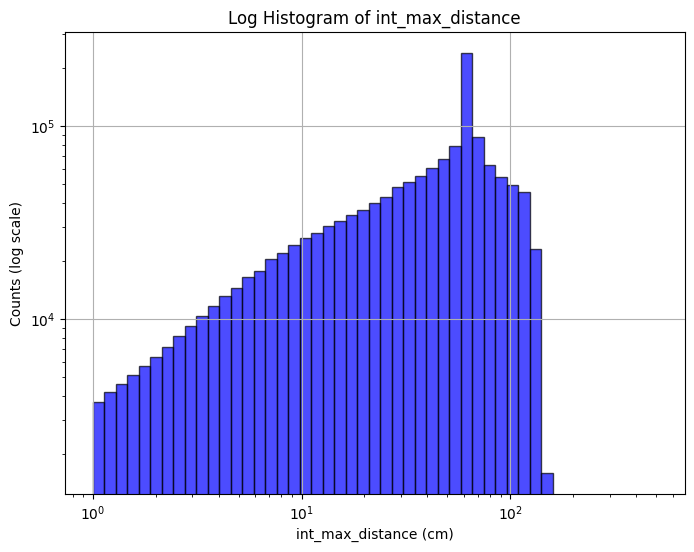

In [16]:
# plot log histogram of int_max_distance
plt.figure(figsize=(8,6))
bins = np.logspace(0, 2.7, 50)  # log-spaced bins from 1 to ~500
plt.hist(df_truth_reco['int_max_distance'], bins=bins, alpha=0.7, color='blue', edgecolor='black', log=True)
plt.title('Log Histogram of int_max_distance')
plt.xlabel('int_max_distance (cm)')
plt.ylabel('Counts (log scale)')
plt.xscale('log')
plt.grid(True)
plt.show()

In [5]:
tpc_bounds_cm = []
mod_bounds_cm = []
filename = '/global/cfs/cdirs/dune/www/data/2x2/simulation/productions/MiniRun6.5_1E19_RHC/MiniRun6.5_1E19_RHC.flow/FLOW/0000000/MiniRun6.5_1E19_RHC.flow.0000000.FLOW.hdf5'
with h5py.File(filename, 'r') as f:
    n_events = f['light/wvfm/data']['samples'].shape[0]
    mod_bounds_cm = np.array(f['geometry_info'].attrs['module_RO_bounds'])
    max_drift_distance = f['geometry_info'].attrs['max_drift_distance']
    for mod in mod_bounds_cm:
        x_min, x_max = mod[0][0], mod[1][0]
        y_min, y_max = mod[0][1], mod[1][1]
        z_min, z_max = mod[0][2], mod[1][2]
        x_min_adj = x_max - max_drift_distance
        x_max_adj = x_min + max_drift_distance
        tpc_bounds_cm.append(((x_min_adj, y_min, z_min), (x_max, y_max, z_max)))
        tpc_bounds_cm.append(((x_min, y_min, z_min), (x_max_adj, y_max, z_max)))
    tpc_bounds_cm = np.array(tpc_bounds_cm)

In [6]:
import scipy.stats as st
from scipy.stats import beta

def clopper_pearson_interval_numpy(k, n, alpha=0.05):
    """
    Vectorized Clopper-Pearson confidence interval for binomial proportions.

    Parameters:
    k : array-like
        Number of successes (can be an array).
    n : array-like
        Number of trials (can be an array).
    alpha : float, optional
        Significance level, default is 0.05 for a 95% confidence interval.

    Returns:
    ci_lower : ndarray
        Lower bound of the confidence interval.
    ci_upper : ndarray
        Upper bound of the confidence interval.
    """
    k = np.asarray(k, dtype=np.int64)
    n = np.asarray(n, dtype=np.int64)

    # Ensure valid values
    if np.any(k > n):
        raise ValueError("Number of successes k cannot be greater than number of trials n")

    alpha_2 = alpha / 2

    # Compute lower bound
    ci_lower = np.where(
        k > 0,
        st.beta.ppf(alpha_2, k, n - k + 1),
        0.0  # If k == 0, lower bound is 0
    )
    #ci_lower -= k/n

    # Compute upper bound
    ci_upper = np.where(
        k < n,
        st.beta.ppf(1 - alpha_2, k + 1, n - k),
        1.0  # If k == n, upper bound is 1
    )
    #ci_upper -= k/n

    return ci_lower, ci_upper

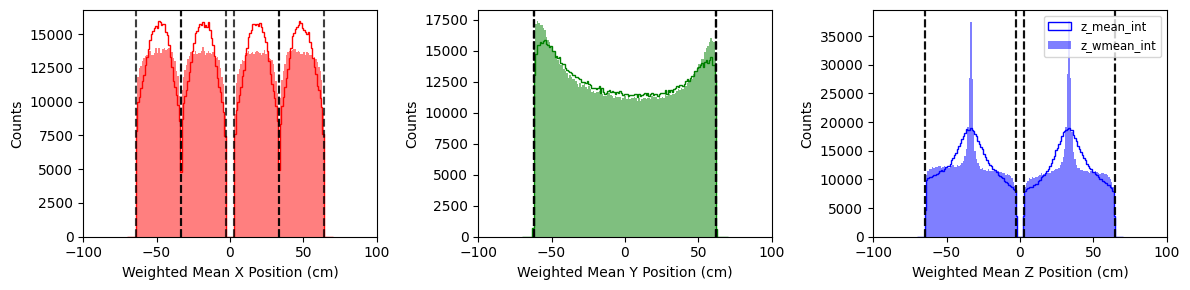

In [7]:
# make histogram of wmean x, y, z
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.hist(df_truth_reco['x_mean_int'], bins=xbins, label='x_mean_int', histtype='step', edgecolor='red')
plt.hist(df_truth_reco['x_wmean_int'], bins=xbins, alpha=0.5, label='x_wmean_int', color='red')
# overlay dashed vertical lines at TPC boundaries
for bounds in tpc_bounds_cm:
    x_min_cm = bounds[0][0]
    x_max_cm = bounds[1][0]
    plt.axvline(x=x_min_cm, color='black', linestyle='dashed', alpha=0.5)
    plt.axvline(x=x_max_cm, color='black', linestyle='dashed', alpha=0.5)
plt.xlabel('Weighted Mean X Position (cm)')
plt.ylabel('Counts')
plt.xlim(-100, 100)
#plt.yscale('log')
plt.subplot(1, 3, 2)
plt.hist(df_truth_reco['y_mean_int'], bins=ybins, label='y_mean_int', histtype='step', edgecolor='green')
plt.hist(df_truth_reco['y_wmean_int'], bins=ybins, alpha=0.5, label='y_wmean_int', color='green')
# overlay dashed vertical lines at TPC boundaries
for bounds in tpc_bounds_cm:
    y_min_cm = bounds[0][1]
    y_max_cm = bounds[1][1]
    plt.axvline(x=y_min_cm, color='black', linestyle='dashed', alpha=0.5)
    plt.axvline(x=y_max_cm, color='black', linestyle='dashed', alpha=0.5)
plt.xlabel('Weighted Mean Y Position (cm)')
plt.ylabel('Counts')
plt.xlim(-100, 100)
#plt.yscale('log')
plt.subplot(1, 3, 3)
plt.hist(df_truth_reco['z_mean_int'], bins=zbins, label='z_mean_int', histtype='step', edgecolor='blue')
plt.hist(df_truth_reco['z_wmean_int'], bins=zbins, alpha=0.5, label='z_wmean_int', color='blue')
# overlay dashed vertical lines at TPC boundaries
for bounds in tpc_bounds_cm:
    z_min_cm = bounds[0][2]
    z_max_cm = bounds[1][2]
    plt.axvline(x=z_min_cm, color='black', linestyle='dashed', alpha=0.5)
    plt.axvline(x=z_max_cm, color='black', linestyle='dashed', alpha=0.5)
plt.xlabel('Weighted Mean Z Position (cm)')
plt.ylabel('Counts')
plt.xlim(-100, 100)
#plt.yscale('log')
plt.tight_layout()
# make legend with hist and step in black for weighted vs unweighted
plt.legend(loc='upper right', fontsize='small')
plt.show()

In [8]:
# remove pileup
df_truth_reco_1int = df_truth_reco[df_truth_reco['n_int_per_tpc'] == 1]

# retain only the events with unique event_id, vertex_id, and tpc_num
df_truth_reco_1int_unique = df_truth_reco_1int.loc[
  df_truth_reco_1int[['file_id', 'event_id', 'vertex_id', 'tpc_num']].drop_duplicates().index
]

# remove events in TPC num 0 & 1
df_truth_reco_1int_unique_mod123 = df_truth_reco_1int_unique[df_truth_reco_1int_unique['tpc_num'] > 1]


# choose the one to use
df_use = df_truth_reco_1int_unique.copy()
#df_use = df_truth_reco_1int_unique_mod123.copy()

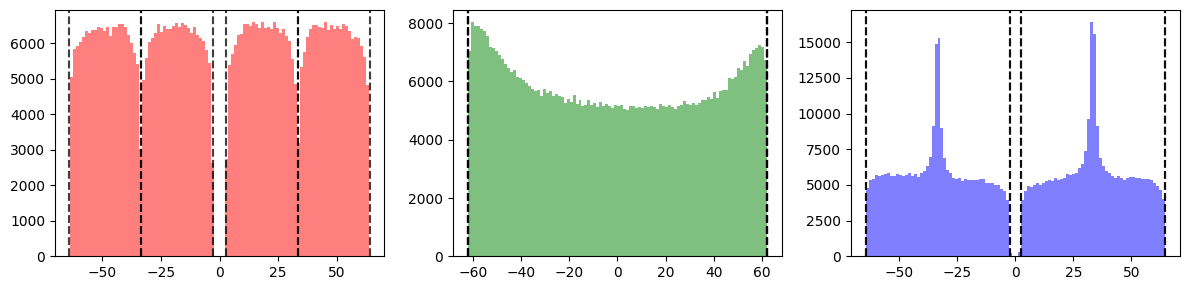

In [9]:
# for the subet of 1int events, make histogram of wmean x, y, z
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.hist(df_use['x_wmean_int'], bins=100, alpha=0.5, label='x_wmean_int', color='red')
# overlay dashed vertical lines at TPC boundaries
for bounds in tpc_bounds_cm:
    x_min_cm = bounds[0][0]
    x_max_cm = bounds[1][0]
    plt.axvline(x=x_min_cm, color='black', linestyle='dashed', alpha=0.5)
    plt.axvline(x=x_max_cm, color='black', linestyle='dashed', alpha=0.5)
plt.subplot(1, 3, 2)
plt.hist(df_use['y_wmean_int'], bins=100, alpha=0.5, label='y_wmean_int', color='green')
# overlay dashed vertical lines at TPC boundaries
for bounds in tpc_bounds_cm:
    y_min_cm = bounds[0][1]
    y_max_cm = bounds[1][1]
    plt.axvline(x=y_min_cm, color='black', linestyle='dashed', alpha=0.5)
    plt.axvline(x=y_max_cm, color='black', linestyle='dashed', alpha=0.5)
plt.subplot(1, 3, 3)
plt.hist(df_use['z_wmean_int'], bins=100, alpha=0.5, label='z_wmean_int', color='blue')
# overlay dashed vertical lines at TPC boundaries
for bounds in tpc_bounds_cm:
    z_min_cm = bounds[0][2]
    z_max_cm = bounds[1][2]
    plt.axvline(x=z_min_cm, color='black', linestyle='dashed', alpha=0.5)
    plt.axvline(x=z_max_cm, color='black', linestyle='dashed', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# define a dataframe where true interactions have at least 1 detector above threshold
det_to_trap_type = [(i % 4 != 0) for i in range(16)]
print(f"det_to_trap_type: {det_to_trap_type}")

# add column for any det_#_max > 1
det_max_cols = [f'det_{i}_max' for i in range(16)]

# mask for acls
acl_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if not trap_type]
df_truth_reco['any_acl'] = (df_truth_reco[acl_max_cols].max(axis=1) > threshold_acl).astype(int)
print(f"acl_max_cols: {acl_max_cols}")

# mask for lcms
lcms_max_cols = [col for col, trap_type in zip(det_max_cols, det_to_trap_type) if trap_type]
df_truth_reco['any_lcm'] = (df_truth_reco[lcms_max_cols].max(axis=1) > threshold_lcm).astype(int)
print(f"lcms_max_cols: {lcms_max_cols}")

# combinded, for any_det == (any_acl or any_lcm)
df_truth_reco['any_det'] = ((df_truth_reco['any_acl'] == 1) | (df_truth_reco['any_lcm'] == 1)).astype(int)

# print number of events with any_det == 1 (and fraction)
print(f"Number of events with any_det == 1: {df_truth_reco['any_det'].sum()}")
print(f"Fraction of events with any_det == 1: {df_truth_reco['any_det'].mean()}")

if det_max_cols:
    # Check ACLs against threshold_acl
    mask_acl = df_use[acl_max_cols].gt(threshold_acl).any(axis=1).fillna(False)
    # Check LCMs against threshold_lcm
    mask_lcm = df_use[lcms_max_cols].gt(threshold_lcm).any(axis=1).fillna(False)
    # Combine: triggered if either ACL or LCM is above threshold
    mask_triggered = mask_acl | mask_lcm
    df_truth_triggered = df_use[mask_triggered].copy()
    df_truth_untriggered = df_use[~mask_triggered].copy()
else:
    print("Warning: No det_#_max columns found; df_truth_triggered will be empty.")
    df_truth_triggered = df_use.iloc[0:0].copy()
    df_truth_untriggered = df_use.copy()

print(f"Number of triggered events: {len(df_truth_triggered)}")

# define bins in x,y,z position 5 cm x 5 cm x 5 cm
x_bins = np.arange(-75, 80, bin_size_cm)
y_bins = np.arange(-75, 80, bin_size_cm)
z_bins = np.arange(-75, 80, bin_size_cm)

# drop rows with NaNs in positions before binning
pos_cols = ['x_wmean_int', 'y_wmean_int', 'z_wmean_int']
df_pos = df_truth_triggered.dropna(subset=pos_cols)

# get the smallest dE_tot per bin in x,y,z for the triggered events
if df_pos.empty:
    df_triggered_binned = pd.DataFrame(columns=['x_bin', 'y_bin', 'z_bin', 'dE_tot'])
else:
    df_triggered_binned = (
        df_pos
        .groupby([
            pd.cut(df_pos['x_wmean_int'], bins=x_bins, include_lowest=True),
            pd.cut(df_pos['y_wmean_int'], bins=y_bins, include_lowest=True),
            pd.cut(df_pos['z_wmean_int'], bins=z_bins, include_lowest=True),
        ], observed=True)
        .agg({'dE_tot': 'min'})
        .reset_index()
        .rename(columns={'x_wmean_int': 'x_bin', 'y_wmean_int': 'y_bin', 'z_wmean_int': 'z_bin'})
    )

print(df_triggered_binned.head())

# untriggered events
df_untriggered_binned = pd.DataFrame(columns=['x_bin', 'y_bin', 'z_bin', 'dE_tot'])
if not df_truth_untriggered.empty:
    df_untriggered_pos = df_truth_untriggered.dropna(subset=pos_cols)
    if not df_untriggered_pos.empty:
        df_untriggered_binned = (
            df_untriggered_pos
            .groupby([
                pd.cut(df_untriggered_pos['x_wmean_int'], bins=x_bins, include_lowest=True),
                pd.cut(df_untriggered_pos['y_wmean_int'], bins=y_bins, include_lowest=True),
                pd.cut(df_untriggered_pos['z_wmean_int'], bins=z_bins, include_lowest=True),
            ], observed=True)
            .agg({'dE_tot': 'min'})
            .reset_index()
            .rename(columns={'x_wmean_int': 'x_bin', 'y_wmean_int': 'y_bin', 'z_wmean_int': 'z_bin'})
        )

print(df_untriggered_binned.head())

det_to_trap_type: [False, True, True, True, False, True, True, True, False, True, True, True, False, True, True, True]
acl_max_cols: ['det_0_max', 'det_4_max', 'det_8_max', 'det_12_max']
lcms_max_cols: ['det_1_max', 'det_2_max', 'det_3_max', 'det_5_max', 'det_6_max', 'det_7_max', 'det_9_max', 'det_10_max', 'det_11_max', 'det_13_max', 'det_14_max', 'det_15_max']
Number of events with any_det == 1: 1935379
Fraction of events with any_det == 1: 0.8390348350199617
Number of triggered events: 647203
            x_bin           y_bin           z_bin     dE_tot
0  (-64.0, -63.0]  (-62.0, -61.0]  (-62.0, -61.0]  12.352510
1  (-64.0, -63.0]  (-62.0, -61.0]  (-61.0, -60.0]  13.786592
2  (-64.0, -63.0]  (-62.0, -61.0]  (-60.0, -59.0]  22.695017
3  (-64.0, -63.0]  (-62.0, -61.0]  (-56.0, -55.0]  33.244984
4  (-64.0, -63.0]  (-62.0, -61.0]  (-51.0, -50.0]  71.781840
            x_bin           y_bin           z_bin    dE_tot
0  (-64.0, -63.0]  (-63.0, -62.0]  (-35.0, -34.0]  0.183604
1  (-64.0, -63

In [11]:
# plot the specified quantile of dE_tot in each (x,y), (x,z), (y,z) bin for chosen events
def plot_dE_tot_heatmaps_div_quantile(
  df_binned,
  quantile=0.5,
  log_scale=False,
  overlay_tpc_bounds=False,
  contour_levels=[1.0],
  contour_kwargs=None
):
  """
  Plot 2D heatmaps of specified quantile of dE_tot in (x,y), (x,z), (y,z) bins for chosen events.
  quantile: float between 0 and 1 specifying which quantile to compute.
  log_scale: if True use log10 color scale (contour_levels interpreted in linear scale then log10'd).
  overlay_tpc_bounds: overlay TPC boundaries as dashed lines.
  contour_levels: list of dE_tot values (linear scale) at which to draw contours (None / empty disables).
  contour_kwargs: optional dict passed to plt.contour (e.g. {'colors':'white','linewidths':1})
  """
  if contour_kwargs is None:
    contour_kwargs = {'colors': 'white', 'linewidths': 1, 'linestyles': 'solid'}

  plt.figure(figsize=(15, 5))

  # (X, Y)
  ax1 = plt.subplot(1, 3, 1)
  x_vals = df_binned['x_bin'].apply(lambda x: x.mid).values
  y_vals = df_binned['y_bin'].apply(lambda y: y.mid).values

  # Compute quantile for each bin
  df_temp = df_binned.copy()
  df_temp['x_idx'] = np.digitize(x_vals, xbins) - 1
  df_temp['y_idx'] = np.digitize(y_vals, ybins) - 1
  H_xy = np.zeros((len(xbins)-1, len(ybins)-1))
  for i in range(len(xbins)-1):
    for j in range(len(ybins)-1):
      mask = (df_temp['x_idx'] == i) & (df_temp['y_idx'] == j)
      if mask.sum() > 0:
        H_xy[i, j] = df_temp.loc[mask, 'dE_tot'].quantile(quantile)
  xedges = xbins
  yedges = ybins

  # (X, Z)
  ax2 = plt.subplot(1, 3, 2)
  z_vals = df_binned['z_bin'].apply(lambda z: z.mid).values
  df_temp['z_idx'] = np.digitize(z_vals, zbins) - 1
  H_xz = np.zeros((len(xbins)-1, len(zbins)-1))
  for i in range(len(xbins)-1):
    for k in range(len(zbins)-1):
      mask = (df_temp['x_idx'] == i) & (df_temp['z_idx'] == k)
      if mask.sum() > 0:
        H_xz[i, k] = df_temp.loc[mask, 'dE_tot'].quantile(quantile)
  xedges2 = xbins
  zedges = zbins
  # (Y, Z)
  ax3 = plt.subplot(1, 3, 3)
  H_zy = np.zeros((len(zbins)-1, len(ybins)-1))
  for k in range(len(zbins)-1):
    for j in range(len(ybins)-1):
      mask = (df_temp['z_idx'] == k) & (df_temp['y_idx'] == j)
      if mask.sum() > 0:
        H_zy[k, j] = df_temp.loc[mask, 'dE_tot'].quantile(quantile)
  zedges2 = zbins
  yedges2 = ybins

  # Prepare data for color scale
  if log_scale:
    data_xy = np.log10(np.where(H_xy > 0, H_xy, np.nan))
    data_xz = np.log10(np.where(H_xz > 0, H_xz, np.nan))
    data_zy = np.log10(np.where(H_zy > 0, H_zy, np.nan))
    cbar_label = 'log10(Quantile dE_tot)'
  else:
    data_xy = H_xy
    data_xz = H_xz
    data_zy = H_zy
    cbar_label = 'Quantile dE_tot'
  # Find symmetric color scale limits
  vmin = np.nanmin([np.nanmin(data_xy), np.nanmin(data_xz), np.nanmin(data_zy)])
  vmax = np.nanmax([np.nanmax(data_xy), np.nanmax(data_xz), np.nanmax(data_zy)])
  abs_max = np.nanmax(np.abs([vmin, vmax]))
  vmin, vmax = -abs_max, abs_max

  # (X, Y)
  im1 = ax1.imshow(
    data_xy.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='bwr', aspect='auto', vmin=vmin, vmax=vmax
  )
  plt.colorbar(im1, ax=ax1, label=cbar_label, shrink=1.0)
  if contour_levels:
    levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
    X = (xedges[:-1] + xedges[1:]) / 2
    Y = (yedges[:-1] + yedges[1:]) / 2
    Xg, Yg = np.meshgrid(X, Y)
    ax1.contour(Xg, Yg, data_xy.T, levels=levels, **contour_kwargs)
  if overlay_tpc_bounds:
    for bounds in tpc_bounds_cm:
      x_min_cm, x_max_cm = bounds[0][0], bounds[1][0]
      y_min_cm, y_max_cm = bounds[0][1], bounds[1][1]
      ax1.axvline(x=x_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax1.axvline(x=x_max_cm, color='k', linestyle='dashed', linewidth=1)
      ax1.axhline(y=y_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax1.axhline(y=y_max_cm, color='k', linestyle='dashed', linewidth=1)
  ax1.set_xlabel('X Position (cm)')
  ax1.set_ylabel('Y Position (cm)')
  # (X, Z)
  im2 = ax2.imshow(
    data_xz.T, origin='lower', extent=[xedges2[0], xedges2[-1], zedges[0], zedges[-1]],
    cmap='bwr', aspect='auto', vmin=vmin, vmax=vmax
  )
  plt.colorbar(im2, ax=ax2, label=cbar_label, shrink=1.0)
  if contour_levels:
    levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
    X = (xedges2[:-1] + xedges2[1:]) / 2
    Z = (zedges[:-1] + zedges[1:]) / 2
    Xg, Zg = np.meshgrid(X, Z)
    ax2.contour(Xg, Zg, data_xz.T, levels=levels, **contour_kwargs)
  if overlay_tpc_bounds:
    for bounds in tpc_bounds_cm:
      x_min_cm, x_max_cm = bounds[0][0], bounds[1][0]
      z_min_cm, z_max_cm = bounds[0][2], bounds[1][2]
      ax2.axvline(x=x_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax2.axvline(x=x_max_cm, color='k', linestyle='dashed', linewidth=1)
      ax2.axhline(y=z_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax2.axhline(y=z_max_cm, color='k', linestyle='dashed', linewidth=1)
  ax2.set_xlabel('X Position (cm)')
  ax2.set_ylabel('Z Position (cm)')
  # (Y, Z)
  im3 = ax3.imshow(
    data_zy.T, origin='lower', extent=[yedges2[0], yedges2[-1], zedges2[0], zedges2[-1]],
    cmap='bwr', aspect='auto', vmin=vmin, vmax=vmax
  )
  plt.colorbar(im3, ax=ax3, label=cbar_label, shrink=1.0)
  if contour_levels:
    levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
    Y = (yedges2[:-1] + yedges2[1:]) / 2
    Z = (zedges2[:-1] + zedges2[1:]) / 2
    Zg, Yg = np.meshgrid(Z, Y)
    ax3.contour(Zg, Yg, data_zy.T, levels=levels, **contour_kwargs)
  if overlay_tpc_bounds:
    for bounds in tpc_bounds_cm:
      y_min_cm, y_max_cm = bounds[0][1], bounds[1][1]
      z_min_cm, z_max_cm = bounds[0][2], bounds[1][2]
      ax3.axvline(x=z_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax3.axvline(x=z_max_cm, color='k', linestyle='dashed', linewidth=1)
      ax3.axhline(y=y_min_cm, color='k', linestyle='dashed', linewidth=1)
      ax3.axhline(y=y_max_cm, color='k', linestyle='dashed', linewidth=1)
  ax3.set_xlabel('Z Position (cm)')
  ax3.set_ylabel('Y Position (cm)')
  plt.tight_layout()
  plt.show()

/tmp/ipykernel_198942/3505355582.py:88: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:110: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:132: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels


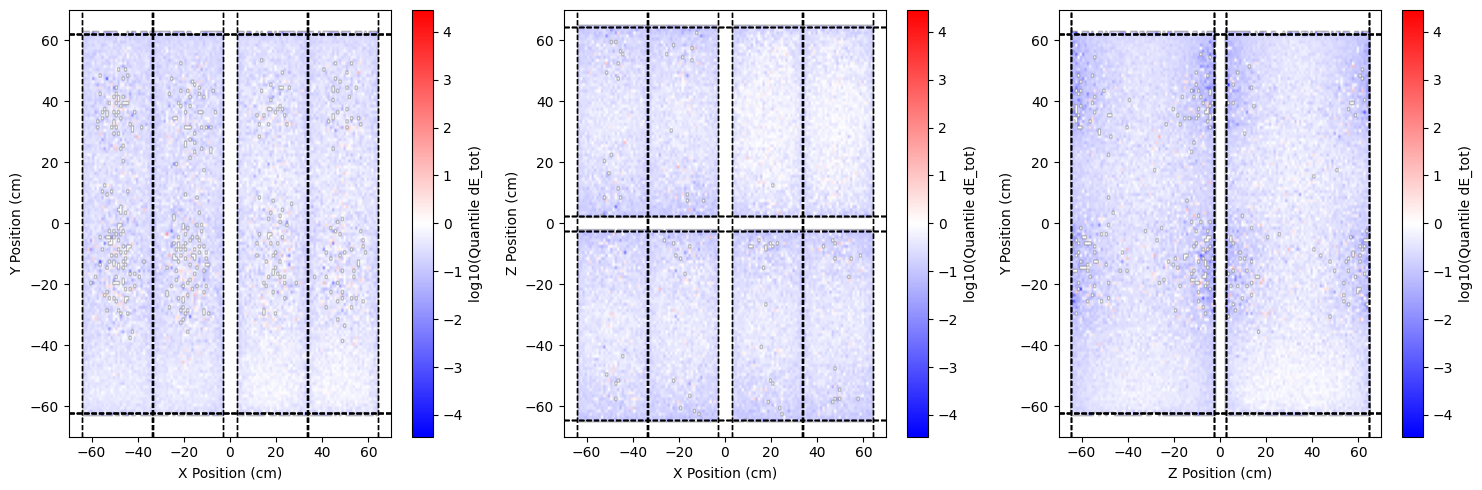

/tmp/ipykernel_198942/3505355582.py:88: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:110: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:132: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels


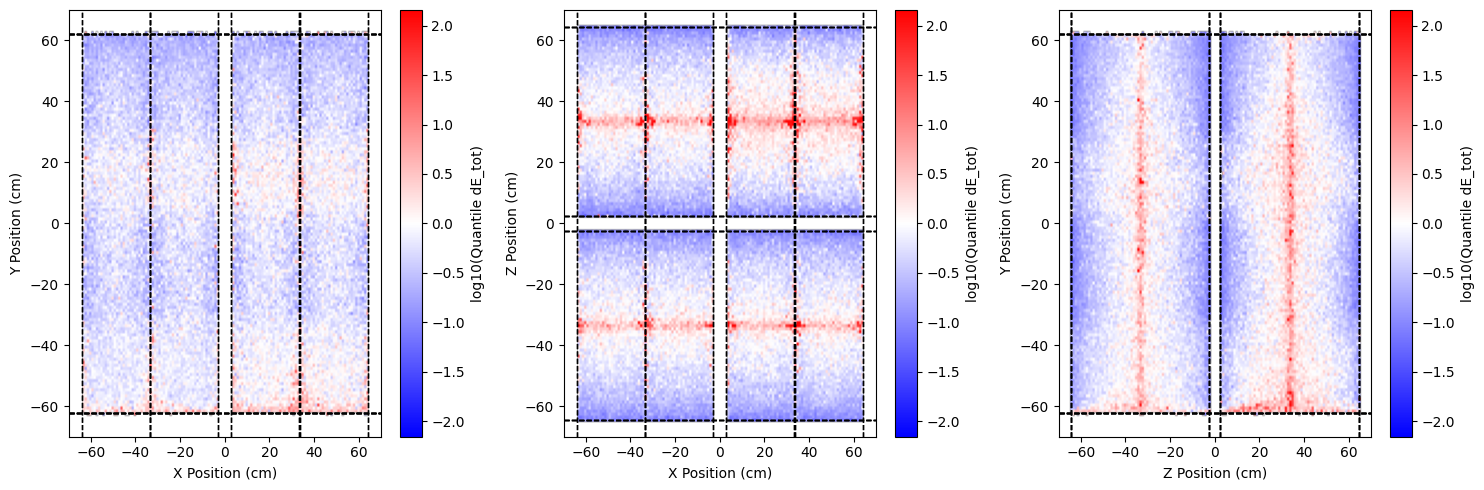

In [12]:
plot_dE_tot_heatmaps_div_quantile(df_untriggered_binned,
                     quantile=0.84,
                     log_scale=True,
                     overlay_tpc_bounds=True,
                     contour_levels=[0],
                     contour_kwargs={'colors':'black',
                                     'linewidths':1})

plot_dE_tot_heatmaps_div_quantile(df_triggered_binned,
                     quantile=0.16,
                     log_scale=True,
                     overlay_tpc_bounds=True,
                     contour_levels=[0],
                     contour_kwargs={'colors':'black',
                                     'linewidths':1})

/tmp/ipykernel_198942/3505355582.py:88: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:110: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:132: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels


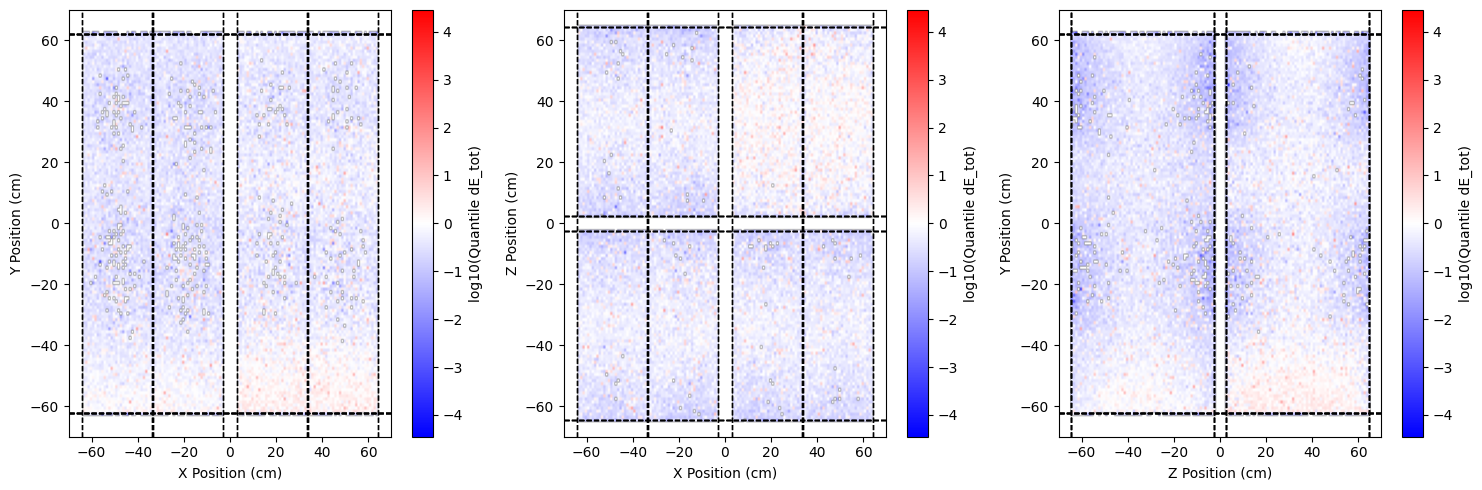

/tmp/ipykernel_198942/3505355582.py:88: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:110: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels
/tmp/ipykernel_198942/3505355582.py:132: RuntimeWarning: divide by zero encountered in log10
  levels = [np.log10(l) for l in contour_levels] if log_scale else contour_levels


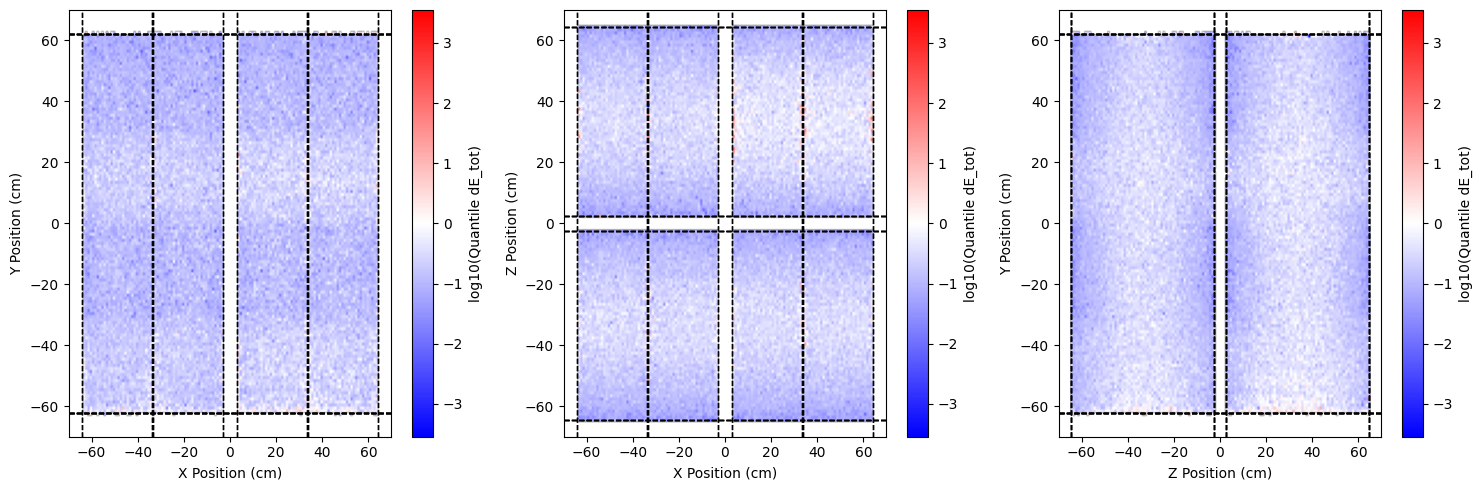

In [13]:
plot_dE_tot_heatmaps_div_quantile(df_untriggered_binned,
                     quantile=1.0,
                     log_scale=True,
                     overlay_tpc_bounds=True,
                     contour_levels=[0],
                     contour_kwargs={'colors':'black',
                                     'linewidths':1})

plot_dE_tot_heatmaps_div_quantile(df_triggered_binned,
                     quantile=0.0,
                     log_scale=True,
                     overlay_tpc_bounds=True,
                     contour_levels=[0],
                     contour_kwargs={'colors':'black',
                                     'linewidths':1})